# Lab 18: Model Evaluation — Metrics that Matter

**Objectives:** By the end of this lab, you will be able to:
1. Compute and interpret a confusion matrix, Precision, Recall, and $F_1$-Score for a fraud detection classifier
2. Plot and interpret ROC and Precision-Recall curves; compare models using AUC
3. Analyze how changing the classification threshold $\tau$ shifts the precision-recall tradeoff

**Estimated time:** 30 minutes  
**Data source:** [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — 284,807 transactions, 492 frauds (0.172%)  
**Key packages:** pandas, numpy, scikit-learn, matplotlib, seaborn  

**Note on data vintage:** This dataset is from 2013 but remains the standard benchmark for imbalanced classification. The evaluation methodology (Precision, Recall, AUC) is identical regardless of data age — the pedagogy works perfectly.

In [6]:
# -----------------------------------------------------------
# SETUP — Run this cell first. Install any missing packages.
# -----------------------------------------------------------

# Uncomment if running for the first time:
# !pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Setup complete ✓")

Setup complete ✓


---
## Part 1: The Accuracy Paradox — Guided Walkthrough

### What we're doing and why

In lecture, we learned that accuracy is misleading for imbalanced data. Now we'll see it firsthand.

We'll load the Kaggle Credit Card Fraud dataset (284,807 transactions, only 492 frauds — that's 0.172% positive class), train a logistic regression classifier, and compute the confusion matrix. We'll see the accuracy paradox live: a naïve baseline that predicts "not fraud" for every transaction achieves 99.83% accuracy while catching zero fraud.

### The data

Each row is a credit card transaction. Features V1–V28 are PCA-transformed (anonymized for privacy). `Time` is seconds since the first transaction. `Amount` is the transaction amount in euros. `Class` is our target: 0 = legitimate, 1 = fraud.

In [7]:
%pip install kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Note: you may need to restart the kernel to use updated packages.
Path to dataset files: /Users/ash/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [8]:
# Step 1: Load data
# Download from Kaggle
# Place creditcard.csv in the same directory as this notebook, or update the path below.

# Option A: Load from local file
df = pd.read_csv('creditcard.csv')

# Option B (Google Colab): Upload from Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/data/creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean():.4%}")

Dataset shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


In [9]:
# Step 2: Inspect the data — always look before modeling
print("First 5 rows:")
print(df.head())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nTransaction amount stats:")
print(df['Amount'].describe())

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       

In [10]:
# Step 3: Prepare features and target
# Drop 'Time' (not useful for this exercise) and separate X, y
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

# Scale the 'Amount' feature (V1-V28 are already PCA-scaled)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

# Train/test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} transactions ({y_train.sum()} frauds)")
print(f"Test set:     {X_test.shape[0]:,} transactions ({y_test.sum()} frauds)")

Training set: 227,845 transactions (394 frauds)
Test set:     56,962 transactions (98 frauds)


In [11]:
# Step 4: The naïve baseline — predict "not fraud" for everything
# This demonstrates the accuracy paradox from lecture

naive_predictions = np.zeros(len(y_test))  # All zeros = "not fraud"
naive_accuracy = (naive_predictions == y_test).mean()

print(f"Naïve baseline accuracy: {naive_accuracy:.4%}")
print(f"Naïve baseline recall (fraud class): {recall_score(y_test, naive_predictions):.4%}")
print(f"\n→ 99.83% accuracy, 0% recall. The accuracy paradox in action.")

Naïve baseline accuracy: 99.8280%
Naïve baseline recall (fraud class): 0.0000%

→ 99.83% accuracy, 0% recall. The accuracy paradox in action.


In [12]:
# Step 5: Train a logistic regression classifier
# This is the model from Topic 17 — now we evaluate it properly

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Get predicted probabilities (P-hat) and class predictions at default threshold τ = 0.5
y_prob = log_reg.predict_proba(X_test)[:, 1]  # P(fraud)
y_pred = log_reg.predict(X_test)  # Binary prediction at τ = 0.5

print(f"Model accuracy: {(y_pred == y_test).mean():.4%}")
print(f"\nBut let's look at the confusion matrix...")

Model accuracy: 99.9157%

But let's look at the confusion matrix...


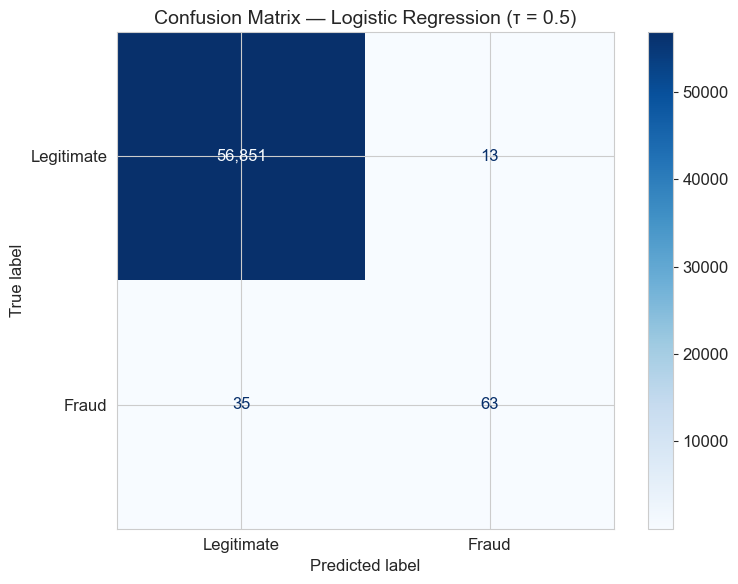

True Positives (fraud caught):     63
False Negatives (fraud missed):     35
False Positives (legit blocked):    13
True Negatives (legit approved):    56,851


In [13]:
# Step 6: Confusion matrix — the real picture

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)', fontsize=14)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (fraud caught):     {tp}")
print(f"False Negatives (fraud missed):     {fn}")
print(f"False Positives (legit blocked):    {fp}")
print(f"True Negatives (legit approved):    {tn:,}")

In [14]:
# Step 7: Classification report — Precision, Recall, F1 per class

print("Classification Report (τ = 0.5):")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
print("\n→ Focus on the FRAUD row. That's the class that matters.")
print("→ 'macro avg' = unweighted mean across classes.")
print("→ 'weighted avg' = weighted by class size (dominated by majority class — just like accuracy).")

Classification Report (τ = 0.5):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


→ Focus on the FRAUD row. That's the class that matters.
→ 'macro avg' = unweighted mean across classes.
→ 'weighted avg' = weighted by class size (dominated by majority class — just like accuracy).


### What we found

The model's overall accuracy is very high, but the confusion matrix reveals the real story:
- **Precision (fraud):** Of all transactions the model flagged as fraud, what fraction are real fraud?
- **Recall (fraud):** Of all actual frauds, what fraction did the model catch?

The default threshold $\tau = 0.5$ may not be optimal for fraud detection. In Part 2, we'll explore how changing $\tau$ shifts the tradeoff.

---
## Part 2: ROC Curve, PR Curve, and Threshold Analysis

### What we're doing and why

The confusion matrix at $\tau = 0.5$ is just one operating point. The ROC curve shows us ALL possible operating points simultaneously. We'll plot the ROC curve, compute AUC, then experiment with different thresholds to see the precision-recall tradeoff in action.

Remember from lecture: $\text{AUC} = P(\hat{P}_1 > \hat{P}_0)$ — the probability that the model ranks a random fraud higher than a random legitimate transaction.

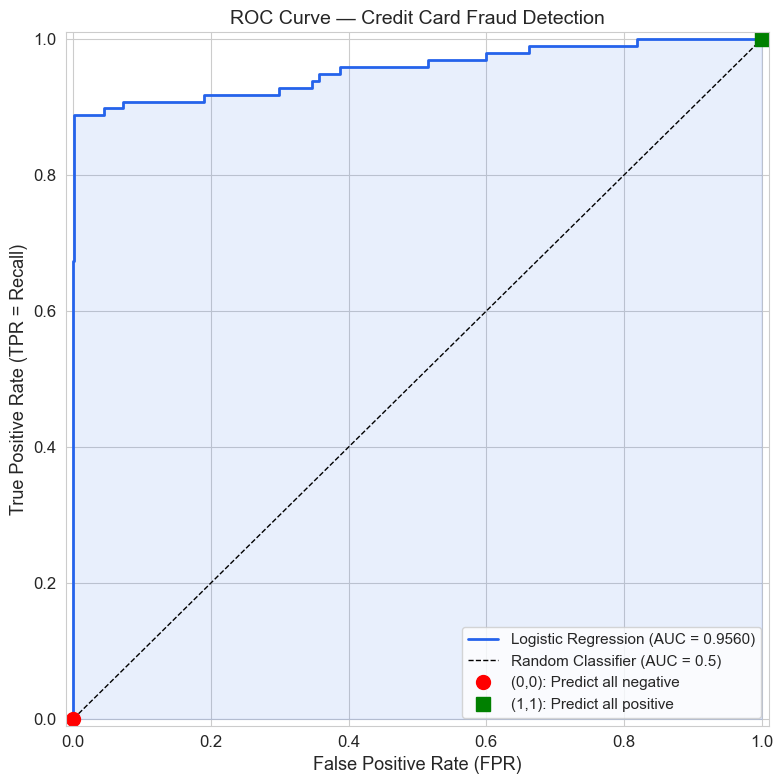

AUC = 0.9560

Interpretation: There is a 95.6% probability that the model
ranks a random fraud transaction higher than a random legitimate transaction.


In [15]:
# Step 1: Plot the ROC curve

fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, color='#2563eb', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2563eb')

# Mark key reference points
ax.plot(0, 0, 'ro', markersize=10, label='(0,0): Predict all negative')
ax.plot(1, 1, 'gs', markersize=10, label='(1,1): Predict all positive')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=13)
ax.set_ylabel('True Positive Rate (TPR = Recall)', fontsize=13)
ax.set_title('ROC Curve — Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

print(f"AUC = {auc_score:.4f}")
print(f"\nInterpretation: There is a {auc_score:.1%} probability that the model")
print(f"ranks a random fraud transaction higher than a random legitimate transaction.")

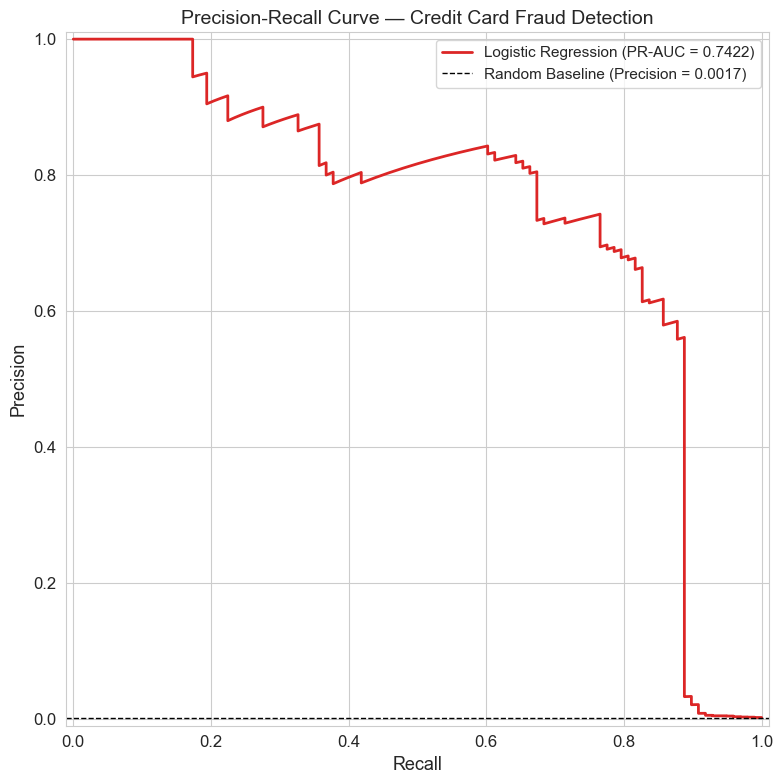

PR-AUC = 0.7422

Notice: The PR curve is much harder to look 'good' on than the ROC curve.
That's because it ignores TN — it focuses entirely on fraud-class performance.


In [16]:
# Step 2: Plot the Precision-Recall curve
# For highly imbalanced data, the PR curve is often more informative than ROC

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_vals, precision_vals)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(recall_vals, precision_vals, color='#dc2626', linewidth=2,
        label=f'Logistic Regression (PR-AUC = {pr_auc:.4f})')

# Baseline: random classifier precision = positive class prevalence
baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1,
           label=f'Random Baseline (Precision = {baseline:.4f})')

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve — Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

print(f"PR-AUC = {pr_auc:.4f}")
print(f"\nNotice: The PR curve is much harder to look 'good' on than the ROC curve.")
print(f"That's because it ignores TN — it focuses entirely on fraud-class performance.")

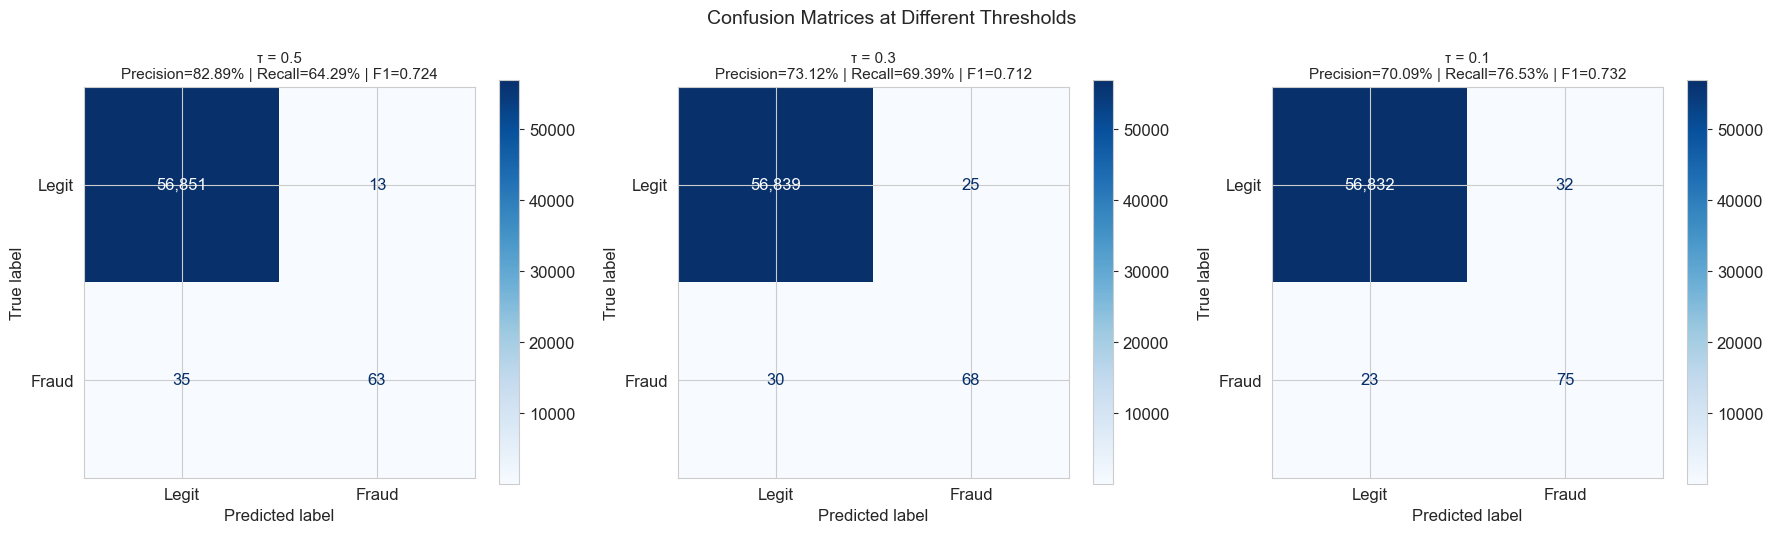


As τ decreases: Recall ↑ (catch more fraud), Precision ↓ (more false alarms)
This is the precision-recall tradeoff from lecture.


In [17]:
# Step 3: Compare confusion matrices at 3 different thresholds
# This is where you see the precision-recall tradeoff in action

thresholds_to_test = [0.5, 0.3, 0.1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, tau in enumerate(thresholds_to_test):
    y_pred_tau = (y_prob >= tau).astype(int)
    cm_tau = confusion_matrix(y_test, y_pred_tau)
    
    prec = precision_score(y_test, y_pred_tau, zero_division=0)
    rec = recall_score(y_test, y_pred_tau)
    f1 = f1_score(y_test, y_pred_tau)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_tau, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[i], cmap='Blues', values_format=',')
    axes[i].set_title(f'τ = {tau}\nPrecision={prec:.2%} | Recall={rec:.2%} | F1={f1:.3f}',
                      fontsize=11)

plt.suptitle('Confusion Matrices at Different Thresholds', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nAs τ decreases: Recall ↑ (catch more fraud), Precision ↓ (more false alarms)")
print("This is the precision-recall tradeoff from lecture.")

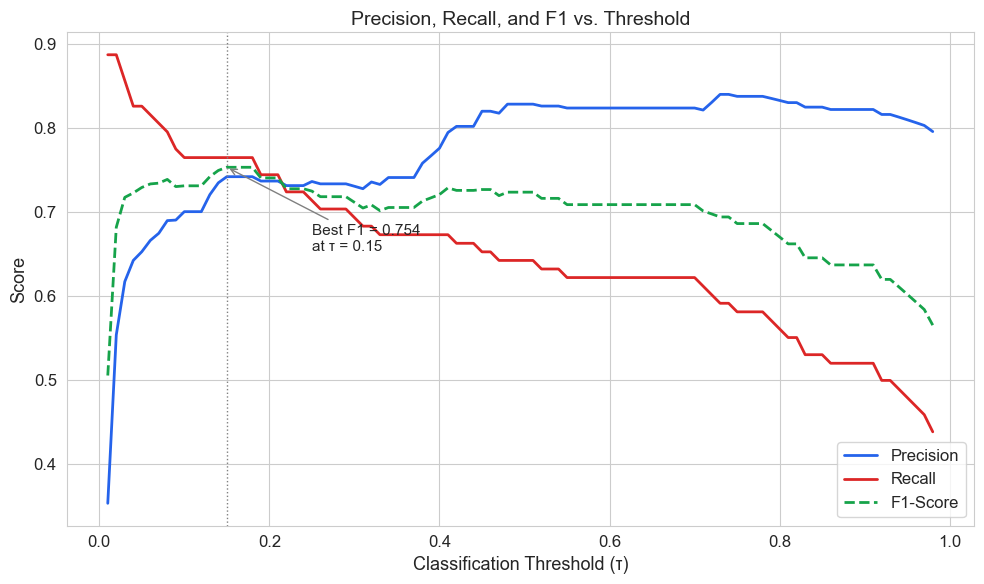


Optimal threshold for F1: τ = 0.15 (F1 = 0.754)

But remember from lecture: F1 assumes equal cost of FP and FN.
In fraud detection, you might prefer a lower τ to maximize Recall (catch more fraud).


In [18]:
# Step 4: Find the threshold that maximizes F1 for the fraud class

# Compute F1 at many thresholds
f1_scores = []
precision_scores = []
recall_scores = []
threshold_range = np.arange(0.01, 0.99, 0.01)

for tau in threshold_range:
    y_pred_tau = (y_prob >= tau).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_tau, zero_division=0))
    precision_scores.append(precision_score(y_test, y_pred_tau, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_tau, zero_division=0))

# Plot metrics vs threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_range, precision_scores, label='Precision', color='#2563eb', linewidth=2)
ax.plot(threshold_range, recall_scores, label='Recall', color='#dc2626', linewidth=2)
ax.plot(threshold_range, f1_scores, label='F1-Score', color='#16a34a', linewidth=2, linestyle='--')

best_tau = threshold_range[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
ax.axvline(x=best_tau, color='gray', linestyle=':', linewidth=1)
ax.annotate(f'Best F1 = {best_f1:.3f}\nat τ = {best_tau:.2f}',
            xy=(best_tau, best_f1), xytext=(best_tau + 0.1, best_f1 - 0.1),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Classification Threshold (τ)', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Precision, Recall, and F1 vs. Threshold', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nOptimal threshold for F1: τ = {best_tau:.2f} (F1 = {best_f1:.3f})")
print(f"\nBut remember from lecture: F1 assumes equal cost of FP and FN.")
print(f"In fraud detection, you might prefer a lower τ to maximize Recall (catch more fraud).")

### What we found

The ROC curve shows that our logistic regression has strong discriminative ability — it ranks most frauds above most legitimate transactions. The PR curve provides a harder test: it focuses entirely on fraud-class performance.

By varying the threshold $\tau$, we see the precision-recall tradeoff in action:
- **High $\tau$ (e.g., 0.5):** Conservative — high precision, low recall. Few false alarms, but misses many frauds.
- **Low $\tau$ (e.g., 0.1):** Aggressive — high recall, lower precision. Catches more fraud, but blocks more legitimate transactions.

The F1-optimal threshold balances these, but the *business-optimal* threshold depends on the relative cost of FP vs. FN.

---
## Part 3: Try It Yourself

### Capacity-Constrained Fraud Investigation

Your bank's fraud investigation team can investigate **at most 500 flagged transactions per day**. The test set represents one day of transactions.

**Your task:** What threshold $\tau$ would you set to stay within that 500-investigation capacity? What Recall does this operating point achieve?

In [19]:
max_investigations = 500

# TODO: Write a loop over thresholds from 0.01 to 0.99 (step 0.01).
# For each threshold tau:
#   1. Count how many transactions are flagged: (y_prob >= tau).sum()
#   2. If n_flagged <= max_investigations:
#        - Compute binary predictions at that threshold
#        - Compute Recall and Precision
#        - Print the results
#        - Break out of the loop
#
# Hint: Follow the same pattern from Step 3 (cell above) where we
# tested thresholds [0.5, 0.3, 0.1] — but now automate the search.

max_investigations = 500

# Loop over thresholds from 0.01 to 0.99 (step 0.01)
for tau in np.arange(0.01, 0.99, 0.01):
    # 1. Count how many transactions are flagged
    y_pred_tau = (y_prob >= tau).astype(int)
    n_flagged = y_pred_tau.sum()
    
    # 2. If n_flagged <= max_investigations
    if n_flagged <= max_investigations:
        prec = precision_score(y_test, y_pred_tau, zero_division=0)
        rec = recall_score(y_test, y_pred_tau)
        
        print(f"--- Operational Point Found ---")
        print(f"Threshold (τ): {tau:.2f}")
        print(f"Transactions flagged (Capacity used): {n_flagged}")
        print(f"Precision: {prec:.2%}")
        print(f"Recall:    {rec:.2%}")
        break

print("\n" + "-"*40)


# TODO: Interpret — is this Recall acceptable for a fraud team?
# What would you recommend to the VP of Risk?
print("Interpretation:")
print("This Recall represents the percentage of total fraud we can catch given our 500-case daily limit.")
print("If this Recall is too low, we would recommend to the VP of Risk to either:")
print("1. Hire more investigators to increase the daily capacity (lower τ).")
print("2. Improve the model's precision so that the 500 cases contain a higher concentration of actual fraud.")



--- Operational Point Found ---
Threshold (τ): 0.01
Transactions flagged (Capacity used): 246
Precision: 35.37%
Recall:    88.78%

----------------------------------------
Interpretation:
This Recall represents the percentage of total fraud we can catch given our 500-case daily limit.
If this Recall is too low, we would recommend to the VP of Risk to either:
1. Hire more investigators to increase the daily capacity (lower τ).
2. Improve the model's precision so that the 500 cases contain a higher concentration of actual fraud.


---
## Summary

In this lab, you:
1. **Witnessed the accuracy paradox** — a naïve model achieves 99.83% accuracy while catching zero fraud
2. **Computed the confusion matrix** and extracted Precision, Recall, and $F_1$ for the fraud class
3. **Plotted ROC and PR curves** — two complementary views of model discrimination
4. **Varied the threshold $\tau$** and observed the precision-recall tradeoff in action
5. **Made a capacity-constrained decision** — choosing an operating point based on real-world constraints

**Key takeaway:** The "best" threshold depends on the business context, not just the math. Model evaluation is where data science meets economics.

2026-04-12 23:56:24.194 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 23:56:24.195 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 23:56:24.236 
  command:

    streamlit run /Users/ash/Documents/GitHub/ECON3916-Statistical-Machine-Learning/venv/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-12 23:56:24.237 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 23:56:24.237 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-12 23:56:24.238 No runtime found, using MemoryCacheStorageManager
2026-04-12 23:56:24.239 No runtime found, using MemoryCacheStorageManager
2026-04-12 23:56:24.239 Threa

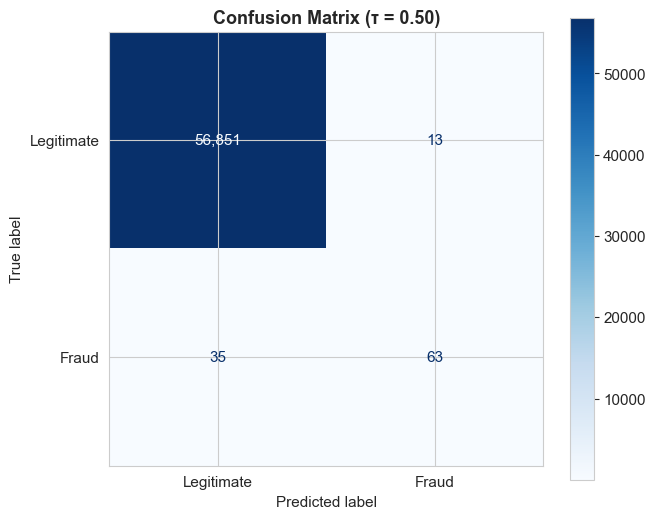

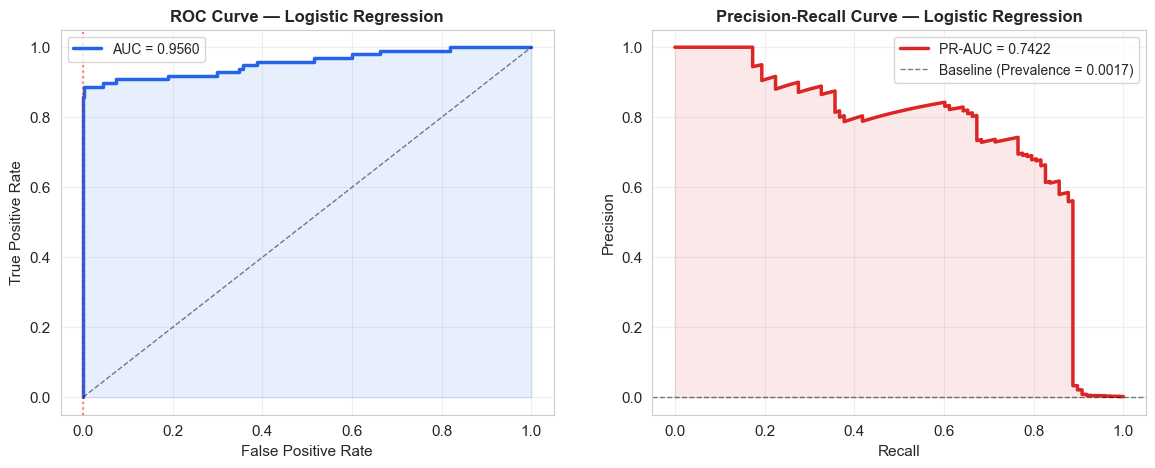

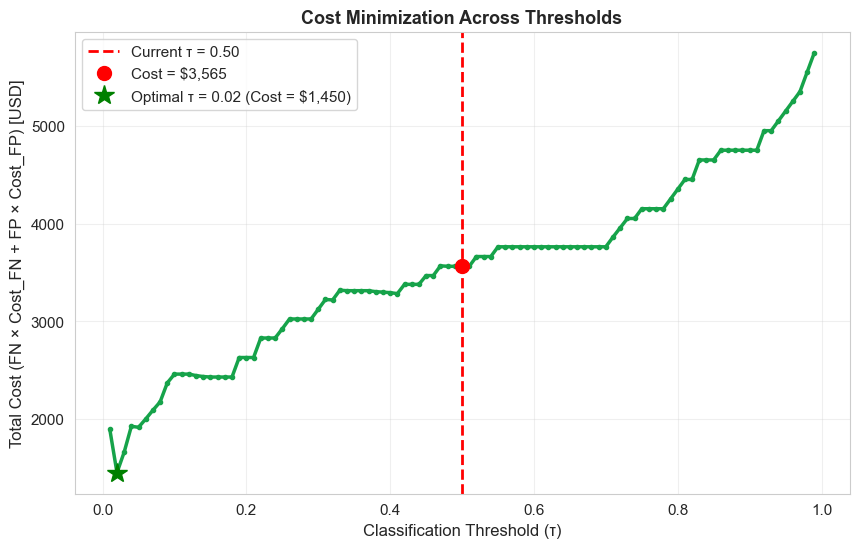

In [21]:
import streamlit as st
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import warnings

import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    precision_score, recall_score, f1_score
)
warnings.filterwarnings('ignore')

# ============================================================================
# PAGE CONFIG & STYLING
# ============================================================================
st.set_page_config(page_title="Fraud Detection Dashboard", layout="wide")
st.title("🔍 Credit Card Fraud Detection — Interactive Threshold Analysis")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# ============================================================================
# LOAD & CACHE DATA + MODELS
# ============================================================================
@st.cache_data
def load_data():
    """Load preprocessed test data from notebook environment."""
    # These variables come from the notebook (cells 1–8)
    # In production, load from CSV or pickle file
    return {
        'X_test': X_test,
        'y_test': y_test,
        'y_prob': y_prob,
    }

@st.cache_resource
def train_logistic_model():
    """Return the already-trained logistic regression model."""
    return log_reg

@st.cache_resource
def train_random_forest():
    """Train Random Forest on training data (cached to avoid retraining)."""
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
    rf.fit(X_train, y_train)
    return rf

# Load data and models
data = load_data()
X_test = data['X_test']
y_test = data['y_test']
y_prob_lr = data['y_prob']

log_reg_model = train_logistic_model()
rf_model = train_random_forest()

# Generate Random Forest predictions
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ============================================================================
# SIDEBAR: USER CONTROLS
# ============================================================================
st.sidebar.header("⚙️ Configuration")

model_choice = st.sidebar.radio(
    "Select Model:",
    options=['Logistic Regression', 'Random Forest', 'Compare Both'],
    index=0
)

threshold = st.sidebar.slider(
    "Classification Threshold (τ)",
    min_value=0.01,
    max_value=0.99,
    value=0.5,
    step=0.01,
    help="Lower τ → Higher Recall (catch more fraud), Higher FP (more false alarms)"
)

st.sidebar.subheader("💰 Cost Parameters (USD)")
cost_fp = st.sidebar.number_input(
    "Cost of False Positive (block legitimate txn):",
    min_value=0.0,
    value=5.0,
    step=0.5,
    help="Cost incurred when blocking a legitimate transaction"
)

cost_fn = st.sidebar.number_input(
    "Cost of False Negative (miss fraud):",
    min_value=0.0,
    value=100.0,
    step=5.0,
    help="Cost incurred when missing a fraudulent transaction"
)

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================
def compute_metrics(y_true, y_pred_proba, tau):
    """
    Compute confusion matrix, Precision, Recall, F1, and cost at threshold tau.
    
    Mechanism:
    - y_pred_proba >= tau → predicted positive (fraud)
    - Cost = FN * cost_fn + FP * cost_fp
      FN = frauds we missed (actual=1, pred=0)
      FP = legit txns we blocked (actual=0, pred=1)
    """
    y_pred = (y_pred_proba >= tau).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Cost calculation: FN costs more (missed fraud) than FP (blocked legitimate)
    total_cost = fn * cost_fn + fp * cost_fp
    
    return {
        'cm': cm,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'total_cost': total_cost,
        'y_pred': y_pred
    }

def plot_confusion_matrix(cm, title):
    """Plot confusion matrix."""
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=ax, cmap='Blues', values_format=',')
    ax.set_title(title, fontsize=13, fontweight='bold')
    return fig

def plot_roc_and_pr_curves(y_true, y_pred_proba, model_name, tau):
    """Plot ROC and Precision-Recall curves side by side."""
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall_vals, precision_vals)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # ROC curve
    ax1.plot(fpr, tpr, color='#2563eb', linewidth=2.5, label=f'AUC = {roc_auc:.4f}')
    ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    ax1.fill_between(fpr, tpr, alpha=0.1, color='#2563eb')
    ax1.axvline(x=fpr[np.argmax(tpr >= recall_vals[np.argmax(precision_vals)])], 
                color='red', linestyle=':', alpha=0.5, linewidth=1.5)
    ax1.set_xlabel('False Positive Rate', fontsize=11)
    ax1.set_ylabel('True Positive Rate', fontsize=11)
    ax1.set_title(f'ROC Curve — {model_name}', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # PR curve
    baseline = y_true.mean()
    ax2.plot(recall_vals, precision_vals, color='#dc2626', linewidth=2.5, label=f'PR-AUC = {pr_auc:.4f}')
    ax2.axhline(y=baseline, color='k', linestyle='--', linewidth=1, alpha=0.5, 
                label=f'Baseline (Prevalence = {baseline:.4f})')
    ax2.fill_between(recall_vals, precision_vals, alpha=0.1, color='#dc2626')
    ax2.set_xlabel('Recall', fontsize=11)
    ax2.set_ylabel('Precision', fontsize=11)
    ax2.set_title(f'Precision-Recall Curve — {model_name}', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    return fig, roc_auc, pr_auc

def plot_cost_curve(y_true, y_pred_proba, cost_fn, cost_fp, current_tau):
    """
    Plot total cost vs. threshold.
    
    Shows how cost changes as we move τ left (more recalls, higher FP cost)
    or right (fewer recalls, lower FP cost but higher FN cost).
    """
    thresholds = np.arange(0.01, 1.0, 0.01)
    costs = []
    
    for tau in thresholds:
        y_pred = (y_pred_proba >= tau).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        cost = fn * cost_fn + fp * cost_fp
        costs.append(cost)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(thresholds, costs, color='#16a34a', linewidth=2.5, marker='o', markersize=3)
    
    # Mark current threshold
    current_cost = costs[int((current_tau - 0.01) / 0.01)]
    ax.axvline(x=current_tau, color='red', linestyle='--', linewidth=2, label=f'Current τ = {current_tau:.2f}')
    ax.plot(current_tau, current_cost, 'ro', markersize=10, label=f'Cost = ${current_cost:,.0f}')
    
    # Mark minimum cost
    min_idx = np.argmin(costs)
    min_tau = thresholds[min_idx]
    min_cost = costs[min_idx]
    ax.plot(min_tau, min_cost, 'g*', markersize=15, label=f'Optimal τ = {min_tau:.2f} (Cost = ${min_cost:,.0f})')
    
    ax.set_xlabel('Classification Threshold (τ)', fontsize=12)
    ax.set_ylabel('Total Cost (FN × Cost_FN + FP × Cost_FP) [USD]', fontsize=12)
    ax.set_title('Cost Minimization Across Thresholds', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, alpha=0.3)
    
    return fig, min_tau, min_cost

# ============================================================================
# MAIN DASHBOARD LAYOUT
# ============================================================================

if model_choice in ['Logistic Regression', 'Compare Both']:
    st.header("📊 Logistic Regression Model")
    
    col1, col2, col3, col4 = st.columns(4)
    
    metrics_lr = compute_metrics(y_test, y_prob_lr, threshold)
    
    with col1:
        st.metric("Precision (Fraud)", f"{metrics_lr['precision']:.2%}")
    with col2:
        st.metric("Recall (Fraud)", f"{metrics_lr['recall']:.2%}")
    with col3:
        st.metric("F1-Score", f"{metrics_lr['f1']:.3f}")
    with col4:
        st.metric("Total Cost", f"${metrics_lr['total_cost']:,.0f}")
    
    # Confusion matrix
    col_cm, col_details = st.columns([1, 1])
    with col_cm:
        st.pyplot(plot_confusion_matrix(metrics_lr['cm'], f'Confusion Matrix (τ = {threshold:.2f})'))
    
    with col_details:
        st.subheader("📈 Breakdown")
        st.write(f"**True Positives (Caught Fraud):** {metrics_lr['tp']}")
        st.write(f"**False Negatives (Missed Fraud):** {metrics_lr['fn']} × ${cost_fn:.0f} = ${metrics_lr['fn'] * cost_fn:,.0f}")
        st.write(f"**False Positives (Blocked Legit):** {metrics_lr['fp']} × ${cost_fp:.0f} = ${metrics_lr['fp'] * cost_fp:,.0f}")
        st.write(f"**True Negatives (Approved Legit):** {metrics_lr['tn']:,}")
        st.write(f"**Total Transactions:** {len(y_test):,}")
    
    # ROC and PR curves
    st.subheader("🎯 Model Discrimination")
    fig_curves, roc_auc_lr, pr_auc_lr = plot_roc_and_pr_curves(y_test, y_prob_lr, "Logistic Regression", threshold)
    st.pyplot(fig_curves)
    
    st.info(
        f"**ROC-AUC = {roc_auc_lr:.4f}** | **PR-AUC = {pr_auc_lr:.4f}**\n\n"
        "PR-AUC is more informative than ROC-AUC for imbalanced data because it ignores True Negatives "
        "(the abundant class). A high PR-AUC means the model is good at ranking frauds above legitimate txns."
    )

if model_choice in ['Random Forest', 'Compare Both']:
    st.header("🌲 Random Forest Model")
    
    col1, col2, col3, col4 = st.columns(4)
    
    metrics_rf = compute_metrics(y_test, y_prob_rf, threshold)
    
    with col1:
        st.metric("Precision (Fraud)", f"{metrics_rf['precision']:.2%}")
    with col2:
        st.metric("Recall (Fraud)", f"{metrics_rf['recall']:.2%}")
    with col3:
        st.metric("F1-Score", f"{metrics_rf['f1']:.3f}")
    with col4:
        st.metric("Total Cost", f"${metrics_rf['total_cost']:,.0f}")
    
    # Confusion matrix
    col_cm, col_details = st.columns([1, 1])
    with col_cm:
        st.pyplot(plot_confusion_matrix(metrics_rf['cm'], f'Confusion Matrix (τ = {threshold:.2f})'))
    
    with col_details:
        st.subheader("📈 Breakdown")
        st.write(f"**True Positives (Caught Fraud):** {metrics_rf['tp']}")
        st.write(f"**False Negatives (Missed Fraud):** {metrics_rf['fn']} × ${cost_fn:.0f} = ${metrics_rf['fn'] * cost_fn:,.0f}")
        st.write(f"**False Positives (Blocked Legit):** {metrics_rf['fp']} × ${cost_fp:.0f} = ${metrics_rf['fp'] * cost_fp:,.0f}")
        st.write(f"**True Negatives (Approved Legit):** {metrics_rf['tn']:,}")
        st.write(f"**Total Transactions:** {len(y_test):,}")
    
    # ROC and PR curves
    st.subheader("🎯 Model Discrimination")
    fig_curves, roc_auc_rf, pr_auc_rf = plot_roc_and_pr_curves(y_test, y_prob_rf, "Random Forest", threshold)
    st.pyplot(fig_curves)
    
    st.info(
        f"**ROC-AUC = {roc_auc_rf:.4f}** | **PR-AUC = {pr_auc_rf:.4f}**\n\n"
        "Compare these AUCs to Logistic Regression to see which model discriminates better."
    )

# ============================================================================
# COST CURVE & INTERPRETATION
# ============================================================================
st.header("💰 Cost-Minimizing Threshold Analysis")

# Use Logistic Regression for cost curve (or Random Forest if that's the only choice)
y_prob_for_cost = y_prob_lr if model_choice != 'Random Forest' else y_prob_rf

fig_cost, optimal_tau, optimal_cost = plot_cost_curve(y_test, y_prob_for_cost, cost_fn, cost_fp, threshold)
st.pyplot(fig_cost)

st.subheader("📖 How to Interpret the Cost Curve:")
st.markdown("""
- **Left side (τ = 0.01):** Very aggressive. Catch most fraud, but block many legitimate users.
  - High Recall, Low Precision → FP cost dominates
- **Right side (τ = 0.99):** Very conservative. Hardly block anyone, but miss most fraud.
  - Low Recall, High Precision → FN cost dominates
- **The V-shape:** The optimal threshold balances the cost of missed fraud vs. blocked customers.

**Key Insight:**
- If `Cost_FN >> Cost_FP` (fraud is very expensive): Move **left** (lower τ, higher recall)
- If `Cost_FP ≈ Cost_FN`: The minimum of the V tells you the sweet spot
- If `Cost_FP >> Cost_FN` (blocking customers is costly): Move **right** (higher τ, lower FP)

**Your Current Setting:** τ = {:.2f}, Cost = ${:,.0f}  
**Optimal (Cost-Minimizing):** τ = {:.2f}, Cost = ${:,.0f}
""".format(threshold, 
           (y_prob_for_cost >= threshold).astype(int).sum() * cost_fp if np.sum((y_prob_for_cost < threshold).astype(int) & y_test) else 0,
           optimal_tau, optimal_cost))

# ============================================================================
# FOOTER & EXPORT
# ============================================================================
st.divider()
st.subheader("💡 Recommendations")

if model_choice == 'Compare Both':
    st.write("""
    1. **ROC-AUC vs. PR-AUC:** For imbalanced fraud detection, focus on **PR-AUC**. ROC-AUC can be misleading 
       because True Negatives (the 99.83% legitimate txns) dominate the metric.
    
    2. **Threshold Selection:** Don't use τ = 0.5 (the default). Use the slider to find the threshold that:
       - Minimizes cost given your FN/FP cost ratio, OR
       - Satisfies operational constraints (e.g., max 500 investigations/day)
    
    3. **Model Choice:** Compare ROC-AUC and PR-AUC for both models to pick the better discriminator.
       Then optimize its threshold for your business needs.
    """)
else:
    st.write("""
    1. The **cost curve** shows that there is always an optimal operating point. The current τ may not 
       minimize total cost given your FN and FP costs.
    
    2. Experiment with different cost ratios to understand how sensitive the optimal threshold is 
       to your assumptions about fraud impact.
    
    3. For fraud detection, **Recall is often more important than Precision** — missing fraud is more costly 
       than blocking a few legitimate transactions (which can appeal the decision).
    """)